# Requirements
## Libraries

In [1]:
import sys
sys.path.append('..')  # Adjust the path as per your directory structure

from scripts.constants import *

import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox

from sedona.spark import *
from pyspark import StorageLevel
from sedona.core.SpatialRDD import PointRDD, PolygonRDD, LineStringRDD
from sedona.core.enums import FileDataSplitter, IndexType, GridType
from sedona.utils.adapter import Adapter
from sedona.core.spatialOperator import JoinQuery

## Variables

In [2]:
# Variables
project_crs = 'EPSG:27700'

# IN paths
imd_lsoa_bua_boundaries_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered_boundaries.geojson"
green_space_path = VECTOR_IN_DIR / "OS" / "Green_Spaces" / "opgrsp_gb.gpkg"
roads_path = VECTOR_IN_DIR / "OS" / "Roads" / "oproad_gb.gpkg"
buildings_path = VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "edition_17_0_new_format.gpkg"
buildings_parquet_path = VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "Buildings_6183.parquet"

# Processing
## GeoDataFrame with Geopandas

In [ ]:
imd_lsoa_bua_gdf = gpd.read_file(imd_lsoa_bua_boundaries_path)

,LSOA11CD,LSOA11NM,LSOA21CD,LSOA21NM,LSOA21NMW,LAD22CD,LAD22NM,LAD22NMW,BUA22CD,BUA22NMW,BUA22NMG,RGN22NMW,BUA22NM,RGN22CD,RGN22NM,geometry
0,E01000001,City of London 001A,E01000001,City of London 001A,None,E09000001,City of London,None,E63004906,None,None,None,City and County of the City of London,E12000007,London,"POLYGON ((532105.092 182011.23, 532162.491 181..."
1,E01000002,City of London 001B,E01000002,City of London 001B,None,E09000001,City of London,None,E63004906,None,None,None,City and County of the City of London,E12000007,London,"POLYGON ((532746.813 181786.891, 532671.688 18..."
2,E01000003,City of London 001C,E01000003,City of London 001C,None,E09000001,City of London,None,E63004906,None,None,None,City and County of the City of London,E12000007,London,"POLYGON ((532135.145 182198.119, 532158.25 182..."
3,E01000005,City of London 001E,E01000005,City of London 001E,None,E09000001,City of London,None,E63004906,None,None,None,City and County of the City of London,E12000007,London,"POLYGON ((533807.946 180767.77, 533649.063 180..."
4,E01000006,Barking and Dagenham 016A,E01000006,Barking and Dagenham 016A,None,E09000002,Barking and Dagenham,None,E63004859,None,None,None,Barking and Dagenham,E12000007,London,"POLYGON ((545122.049 184314.931, 545271.917 18..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36534,E01033764,Liverpool 022E,E01034399,Liverpool 022G,None,E08000012,Liverpool,None,E63001374,None,None,None,Liverpool,E12000002,North West,"POLYGON ((334934.507 393421.201, 334921.819 39..."
36535,E01033765,Liverpool 061D,E01033765,Liverpool 061D,None,E08000012,Liverpool,None,E63001374,None,None,None,Liverpool,E12000002,North West,"POLYGON ((335087 388951, 335125 388808, 335162..."
36536,E01033766,Liverpool 042G,E01034404,Liverpool 042H,None,E08000012,Liverpool,None,E63001374,None,None,None,Liverpool,E12000002,North West,"POLYGON ((338804.207 388364.881, 338831.644 38..."
36537,E01033767,Liverpool 050J,E01033767,Liverpool 050J,None,E08000012,Liverpool,None,E63001374,None,None,None,Liverpool,E12000002,North West,"POLYGON ((335584.014 387799.682, 335678 387721..."


<Axes: >

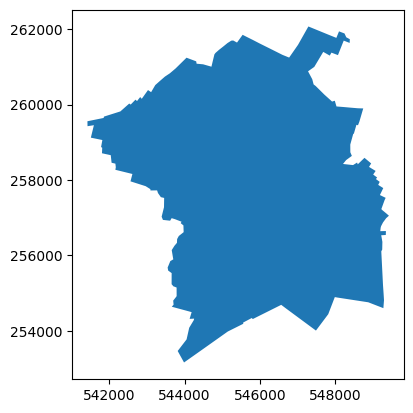

In [ ]:
geo_level = 'LAD22CD'
geo_code = 'E07000008'
geo_boundary_gdf = imd_lsoa_bua_gdf[imd_lsoa_bua_gdf[geo_level] == geo_code].dissolve()[['geometry', geo_level]]
geo_boundary_gdf.plot()

In [7]:
print(gpd.list_layers(roads_path))
print(gpd.list_layers(green_space_path))
print(gpd.list_layers(buildings_path))

                name geometry_type
0  motorway_junction         Point
1          road_link    LineString
2          road_node         Point
              name geometry_type
0     access_point         Point
1  greenspace_site  MultiPolygon
                      name geometry_type
0  edition_17_0_new_format       Unknown
1             layer_styles       Unknown


In [49]:
%%time
green_space_access_gdf = gpd.read_file(green_space_path, layer='access_point')
green_space_site_gdf = gpd.read_file(green_space_path, layer='greenspace_site')
road_edges_gdf = gpd.read_file(roads_path, layer='road_link')
road_nodes_gdf = gpd.read_file(roads_path, layer='road_node')

CPU times: user 55.3 s, sys: 11.8 s, total: 1min 7s
Wall time: 1min 7s


In [22]:
buildings_columns = ['verisk_building_id', 'premise_year', 'premise_use', 'premise_type',
 'premise_floor_count', 'height', 'building_area', 'distance_building', 'distance_water', 
 'map_use', 'map_simple_use', 'geometry']
buildings_gdf = gpd.read_file(buildings_path, layer='edition_17_0_new_format', columns=buildings_columns)
# buildings_gdf.to_parquet(buildings_parquet_path)
# buildings_gdf.to_file(VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "Buildings_6183.geojson")
# # buildings_gdf.to_file(VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "Buildings_6183.shp") # Didn't write all polygons

In [ ]:
public_park_site_gdf = green_space_site_gdf.copy()[green_space_site_gdf['function'] == 'Public Park Or Garden']
public_park_access_gdf = green_space_access_gdf.copy()[green_space_access_gdf['ref_to_greenspace_site'].isin(public_park_site_gdf.id)]

## Network Analysis with Networkx

In [128]:
geo_public_park_site_gdf = gpd.sjoin(public_park_site_gdf, geo_boundary_gdf).reset_index(drop=True)
geo_public_park_access_gdf = gpd.sjoin(public_park_access_gdf, geo_boundary_gdf).reset_index(drop=True)
geo_road_nodes_gdf = gpd.sjoin(road_nodes_gdf, geo_boundary_gdf)\
    .rename(columns={'id': 'osmid'})\
    .set_index(['osmid'])
geo_road_edges_gdf = road_edges_gdf[(road_edges_gdf['start_node'].isin(geo_road_nodes_gdf.index)) & (road_edges_gdf['end_node'].isin(geo_road_nodes_gdf.index))]\
    .rename(columns={'start_node': 'u', 'end_node': 'v', 'id': 'key'})\
    .set_index(['u', 'v', 'key'])
geo_road_nodes_gdf['x'] = geo_road_nodes_gdf.geometry.x
geo_road_nodes_gdf['y'] = geo_road_nodes_gdf.geometry.y
# geo_buildings_gdf = gpd.sjoin(buildings_gdf, geo_boundary_gdf).reset_index(drop=True)

In [132]:
geo_graph = ox.graph_from_gdfs(geo_road_nodes_gdf, geo_road_edges_gdf)

In [135]:
ox.distance.nearest_nodes(geo_graph, geo_buildings_gdf.geometry.centroid.x[0], geo_buildings_gdf.geometry.centroid.y[0])

ImportError: scipy must be installed as an optional dependency to search a projected graph.

## GeoDataFrame with Apache Sedona

In [ ]:
def get_spark():
    config = (
        SedonaContext.builder()
        .config(
            "spark.jars.packages",
            "org.apache.sedona:sedona-spark-3.5_2.12:1.6.1,"
            "org.datasyslab:geotools-wrapper:1.6.1-28.2,"
            "net.postgis:postgis-jdbc:2021.1.0,"
            "net.postgis:postgis-geometry:2021.1.0,"
            "org.postgresql:postgresql:42.5.4,",
        )
        .config(
            "spark.jars.repositories",
            "https://artifacts.unidata.ucar.edu/repository/unidata-all",
        )
        # Shapefile WKT strings can get very long -- show more debugging info
        .config("spark.sql.debug.maxToStringFields", 10000)
        # No. of partitions given to the result of a shuffle by default.
        # (i.e. output of any rekeying of data)
        .config("spark.default.parallelism", 200)
        # Do not allow Spark to automatically coalesce partitions after shuffle
        # when it thinks that the data size is small enough to fit in one
        # partition. Often, we are using a large number of partitions to distribute large data resources that Spark does not know about.
        # Call coalese() explicitly after a shuffle when this behavior is
        # desired.
        # https://spark.apache.org/docs/latest/sql-performance-tuning.html#adaptive-query-execution
        .config("spark.sql.adaptive.coalescePartitions.enabled", False)
        .config("spark.executor.memory", "8g")
        .config("spark.driver.memory", "32g")
        # Configure max number of concurrent tasks and allowable task failures
        # for spark in local mode.
        # https://spark.apache.org/docs/2.2.0/submitting-applications.html#master-urls
        # Format: local[num_tasks, num_failures]
        # N.b. Restrict number of concurrent tasks to
        #       1. Play nicely with other users on a shared machine
        #       2. Slow Spark down, esp. when tasks use resources spark doesn't
        #           know about. E.g. Querying a DB, making web requests,
        #           opening large files, etc.
        # N.b. Set max failures to 0 in development. Increase for deployment.
        .master("local[10,0]")
    ).getOrCreate()
    return SedonaContext.create(config)

sedona = get_spark()

24/12/02 13:34:54 WARN Utils: Your hostname, kinabalu resolves to a loopback address: 127.0.1.1; using 128.232.93.1 instead (on interface eno12399np0)
24/12/02 13:34:54 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
https://artifacts.unidata.ucar.edu/repository/unidata-all added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/acz25/.ivy2/cache
The jars for the packages stored in: /home/acz25/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
net.postgis#postgis-jdbc added as a dependency
net.postgis#postgis-geometry added as a dependency
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f2982dc9-2723-4160-8d8e-7efb1285bcc0;1.0
	confs: [default]


:: loading settings :: url = jar:file:/maps-priv/maps/acz25/miniconda3/envs/3-30-300-health-env/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.apache.sedona#sedona-spark-3.5_2.12;1.6.1 in central
	found org.apache.sedona#sedona-common;1.6.1 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.19.0 in central
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-annotations;1.1 in central
	found org.codehaus.mojo#animal-sniffer-annotations;1.14 in central
	found com.uber#h3;4.1.1 in central
	found net.sf.geographiclib#GeographicLib-Java;1.52 in central
	found com.github.ben-manes.caffeine#caffeine;2.9.2 in central
	found org.checkerframework#checker-qual;3.10.0 in central
	found com.google.error

In [9]:
buildings_rdd = sedona.read.format("geoparquet").load(str(buildings_parquet_path))
buildings_rdd.printSchema()

root
 |-- building_area: double (nullable = true)
 |-- distance_building: float (nullable = true)
 |-- distance_water: double (nullable = true)
 |-- height: double (nullable = true)
 |-- map_simple_use: string (nullable = true)
 |-- map_use: string (nullable = true)
 |-- premise_floor_count: string (nullable = true)
 |-- premise_type: string (nullable = true)
 |-- premise_use: string (nullable = true)
 |-- premise_year: double (nullable = true)
 |-- verisk_building_id: long (nullable = true)
 |-- geometry: geometry (nullable = true)



In [ ]:
lsoa_boundaries_rdd = sedona.createDataFrame(imd_lsoa_bua_gdf.drop(['LSOA21NMW', 'LAD22NMW', 'BUA22NMG', 'RGN22NMW'], axis=1))
lsoa_boundaries_rdd.createOrReplaceTempView("lsoa_boundaries")
green_spaces_access_rdd = sedona.createDataFrame(green_space_access_gdf)
green_spaces_access_rdd.createOrReplaceTempView("green_spaces_access")
green_spaces_sites_rdd = sedona.createDataFrame(green_space_site_gdf.drop(['distinctive_name_4'], axis=1))
green_spaces_sites_rdd.createOrReplaceTempView("green_spaces_sites")
roads_rdd = sedona.createDataFrame(roads_gdf.drop(['name_1_lang', 'name_2', 'name_2_lang'], axis=1))
roads_rdd.createOrReplaceTempView("roads")

In [28]:
public_parks_sites_rdd = sedona.sql(
    """
    SELECT * FROM green_spaces_sites
    WHERE function = 'Public Park Or Garden';
    """
)
public_parks_sites_rdd.createOrReplaceTempView("public_parks_sites")
public_parks_sites_rdd.show()

+--------------------+--------------------+--------------------+------------------+------------------+--------------------+
|                  id|            function|  distinctive_name_1|distinctive_name_2|distinctive_name_3|            geometry|
+--------------------+--------------------+--------------------+------------------+------------------+--------------------+
|14F2FCB0-85FF-48C...|Public Park Or Ga...|Holytown Cremator...|              NULL|              NULL|MULTIPOLYGON (((2...|
|1E275099-9C22-355...|Public Park Or Ga...|                NULL|              NULL|              NULL|MULTIPOLYGON (((5...|
|1E275099-9D7B-355...|Public Park Or Ga...|                NULL|              NULL|              NULL|MULTIPOLYGON (((3...|
|1E275099-9E04-355...|Public Park Or Ga...|                NULL|              NULL|              NULL|MULTIPOLYGON (((3...|
|1E275099-9FDE-355...|Public Park Or Ga...|                NULL|              NULL|              NULL|MULTIPOLYGON (((5...|
|1E27509

In [ ]:
public_parks_access_rdd = sedona.sql(
    """
    SELECT * FROM green_spaces_access
    WHERE ref_to_greenspace_site IN (SELECT id FROM public_parks_sites)
    """)
public_parks_access_rdd.createOrReplaceTempView("public_parks_access")
public_parks_access_rdd.show()

+--------------------+--------------------+----------------------+--------------------+
|                  id|         access_type|ref_to_greenspace_site|            geometry|
+--------------------+--------------------+----------------------+--------------------+
|9AE82EB3-9B47-401...|          Pedestrian|  1E275110-A202-355...|POINT (434710.03 ...|
|0582F087-4D2F-480...|          Pedestrian|  1E2750A1-3109-355...|POINT (433707.56 ...|
|85A589DA-3869-489...|          Pedestrian|  1E275221-E4E4-355...|POINT (331066.06 ...|
|8B3D1CD5-F5BD-400...|          Pedestrian|  1E27509A-30B5-355...|POINT (312144.82 ...|
|363C0E4E-F151-40D...|          Pedestrian|  1E27509E-0E29-355...|POINT (337981.93 ...|
|2E832742-CC5B-4C7...|          Pedestrian|  1E2750A4-372D-355...|POINT (359166.93 ...|
|F0D80AF0-91E3-42E...|          Pedestrian|  1E2750A4-6294-355...|POINT (392081.38 ...|
|97615B9D-AEF6-499...|          Pedestrian|  1E2750F7-4F76-355...|POINT (389219.02 ...|
|BDB11932-63A7-4EA...|          

In [ ]:
from sedona.core.spatialOperator import KNNQuery

k = 2
using_index = True
result = KNNQuery.SpatialKnnQuery(buildings_rdd, public_parks_access_rdd, k, using_index)

In [ ]:
roads_network = sedona.sql(
    """
    SELECT id, ST_LineMerge(ST_Collect(geometry)) AS geom
    FROM roads;
    """
)
roads_network.createOrReplaceTempView("roads_network")

In [ ]:
# buildings_network = sedona.sql(
#     """
#     SELECT b.verisk_building_id, 
#        ST_DumpPoints(ST_ClosestPoint(n.geom, ST_Centroid(b.geometry)))[0] AS network_point
#     FROM buildings b, roads_network n;
#     """
# )
# public_park_network = sedona.sql(
#     """
#     SELECT p.id, 
#        ST_DumpPoints(ST_ClosestPoint(n.geom, ST_Centroid(p.geometry)))[0] AS network_point
#     FROM public_park_access p, roads_network n;
#     """
# )
# buildings_network.createOrReplaceTempView("buildings_network")
# public_park_network.createOrReplaceTempView("public_park_network")

# Spatial RDD

In [ ]:
# %%time
# closest_park = sedona.sql(
#     """
#     WITH distances AS (
#     SELECT p.verisk_building_id AS polygon_id, 
#             pt.id AS point_id,
#             ST_Distance(p.network_point, pt.network_point) AS network_distance
#     FROM buildings_network p
#     CROSS JOIN public_park_network pt
#     WHERE ST_DWithin(p.network_point, pt.network_point, 1000)  -- Adjust the distance as needed
#     ),
#     ranked_distances AS (
#     SELECT polygon_id,
#             point_id,
#             network_distance,
#             ROW_NUMBER() OVER (PARTITION BY polygon_id ORDER BY network_distance) AS rank
#     FROM distances
#     )
#     SELECT polygon_id, 
#         point_id, 
#         network_distance
#     FROM ranked_distances
#     WHERE rank <= 2  -- Change this to get more or fewer nearest neighbors
#     ORDER BY polygon_id, network_distance;
#     """
# )
# closest_park.createOrReplaceTempView("closest_park")

In [ ]:
# closest_park.show(20)

In [ ]:
# closest_park_df = closest_park.toPandas()
# closest_park_df